# Complete runthrough

A step-by-step walkthrough of the full pipeline, from raw Gutenberg downloads through to a trained model generating text. Each section uses one of the core classes described in the [README](../README.md#code-layout), in the order they're meant to be used. Some steps (downloading/cleaning 634 books, training the tokeniser, training the model) are genuinely slow and this notebook is meant as a reference for how the pieces fit together, not something to blindly run.

## 1. Data Pipeline: `TheFarmer`

Downloads philosophy books from Project Gutenberg, cleans the raw text, and runs sanity checks on the result. This is the slowest part of the pipeline end-to-end (downloading 634 books, one request per second, takes a while). `TheFarmer` skips any book it's already downloaded, so it's safe to re-run.

In [1]:
from socrates_ai.data_prep import TheFarmer

farmer = TheFarmer()

In [ ]:
farmer.set_data_destination()

In [ ]:
farmer.retrieve_gutenberg_books()

In [ ]:
farmer.farm_philosophy_books()

In [ ]:
farmer.clean_books()

In [ ]:
farmer.check_cleaned_data()

## 2. Exploratory Data Analysis: `EDAPainter`

A quick look at the cleaned corpus before spending time training a tokeniser/model on it. Corpus size, vocabulary richness, and sentence length style per book. Reads straight from `farmer.metadata_path` / `farmer.clean_dir`, so it works even in a fresh kernel as long as `clean_books()` has already been run once.

In [2]:
from socrates_ai.data_prep import EDAPainter

painter = EDAPainter(metadata_path=farmer.metadata_path, clean_dir=farmer.clean_dir)

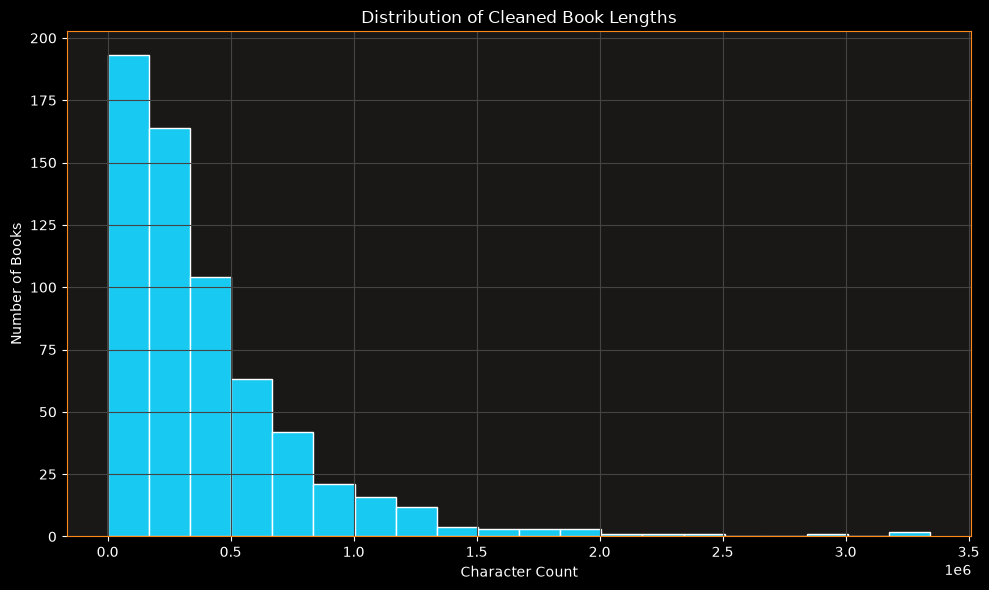

In [3]:
painter.plot_length_distribution()

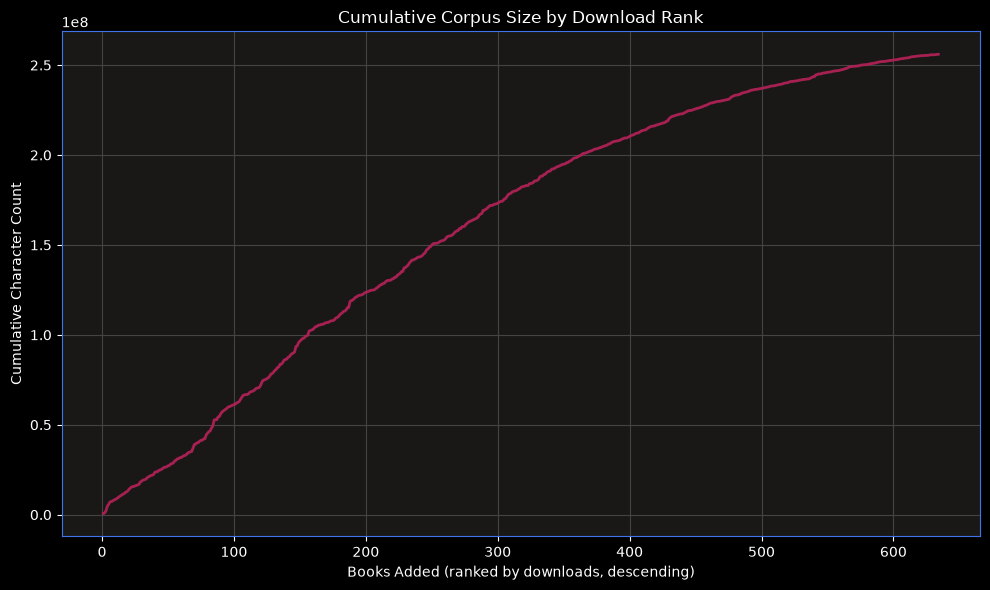

Total corpus size: 256,005,413 characters across 634 books


In [4]:
painter.plot_cumulative_corpus_size()

) missing from font(s) DejaVu Sans._Projects/Socrates_AI/socrates_ai/data_prep.py:328: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans._Projects/Socrates_AI/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


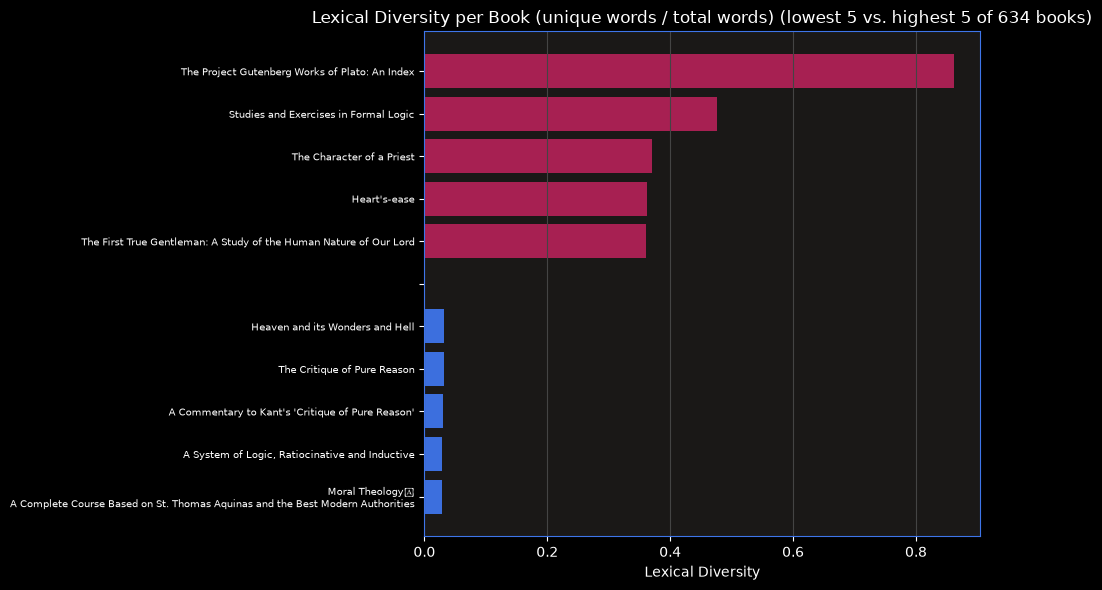

In [ ]:
# May take a while to run for the first time as this build self.eda_df,
# which buildsa a dataframe from all metadata info

painter.plot_lexical_diversity()

) missing from font(s) DejaVu Sans._Projects/Socrates_AI/socrates_ai/data_prep.py:328: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans._Projects/Socrates_AI/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


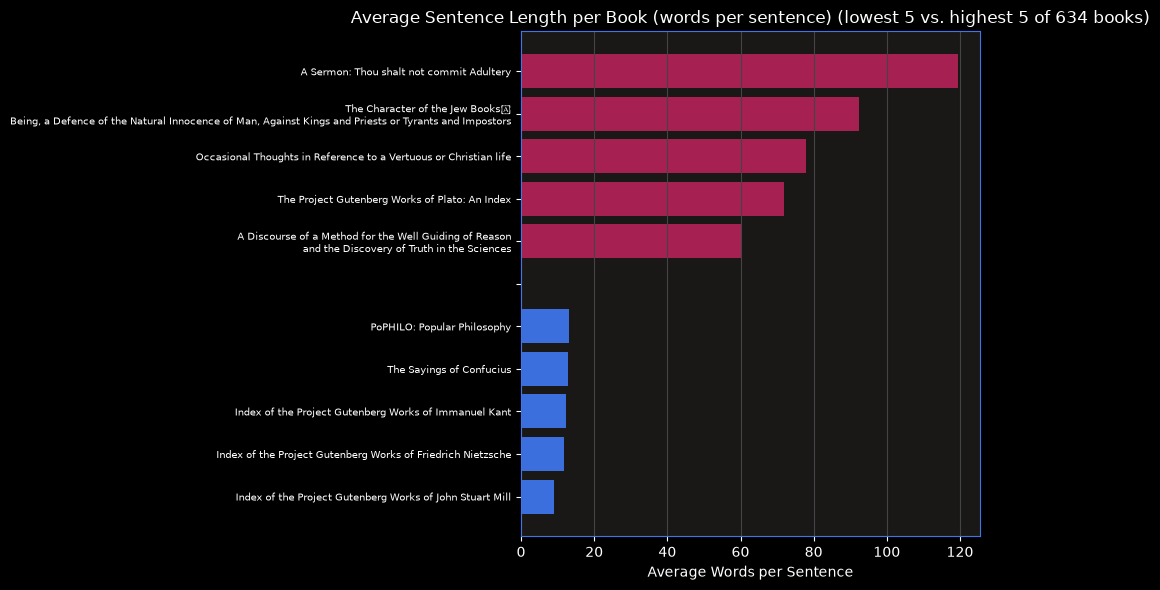

In [ ]:
painter.plot_avg_sentence_length()

## 3. Tokenisation: `Translator`

Trains a byte-level BPE tokeniser directly on the cleaned corpus (not a pretrained vocabulary), then saves and reloads it to confirm it round-trips correctly.

In [ ]:
from socrates_ai.model_prep import Translator

books_path = farmer.clean_dir
translator = Translator(cleaned_books_path=books_path, Vocab_size=16000)

In [ ]:
translator.train_tokeniser()

In [ ]:
translator.tokeniser_path

In [ ]:
oracle_tokens = translator.load_tokeniser()

In [ ]:
translator.test_tokeniser(tokeniser=oracle_tokens)

## 4. Preparing Train/Val Data

Tokenises every cleaned book with the trained tokeniser and splits by **whole book** (not a slice of the concatenated token stream) into train/val sets as this tests generalisation to books the model has never seen any part of, not just memorised continuations. This is the slow step (~5 minutes across the full corpus), not the split itself.

In [ ]:
from socrates_ai.helpers.training_helpers import load_book_paths, split_books_train_val

book_paths = load_book_paths(farmer.clean_dir)
print(f"{len(book_paths)} cleaned books found")

In [ ]:
train_ids, val_ids = split_books_train_val(book_paths, oracle_tokens)
print(f"train tokens: {len(train_ids):,}")
print(f"val tokens:   {len(val_ids):,}")

## 5. Model: `MiniTransformer`

A from scratch decoder only transformer, please see the [README](../README.md#architecture--training) for the architecture details. `vocab_size` comes straight from the trained tokeniser so it can never drift out of sync with it.

In [ ]:
import torch
from socrates_ai.model_prep import MiniTransformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = MiniTransformer(
    vocab_size=oracle_tokens.get_vocab_size(),
    d_model=256,
    n_layers=4,
    n_heads=4,
    block_size=128,
    dropout=0.1,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

## 6. Training: `TrainingSocrates`

Owns the whole training loop: batching, the AdamW optimiser, the warmup + cosine decay LR schedule, gradient clipping, and checkpointing. Checkpoints save automatically during training, so a run can be safely interrupted and resumed with `load_checkpoint()`.

In [ ]:
from socrates_ai.training import TrainingSocrates

trainer = TrainingSocrates(model, train_ids, val_ids, device=device)

In [ ]:
# uncomment to resume from the most recent checkpoint
# trainer.load_checkpoint()

In [ ]:
# max_steps kept small here just to demonstrate the method a real training
# run needs thousands of steps and if you don't have alot of compute like me,
# I've been doing them overnight

trainer.train(max_steps=100, eval_interval=20, eval_iters=10)

In [ ]:
trainer.plot_training_curves()

## 7. Generating Text

`talk()` handles the full string-in, string-out round trip (encode -> autoregressive generation -> decode).

In [ ]:
print(trainer.talk(tokeniser=oracle_tokens, prompt="The greatest happiness", temperature=0.85))